# Person 4 — Neural Sequential Model: Transformer Encoder for Swahili Audio Classification

**Purpose:** develop and evaluate Person 4's assigned neural sequential model on the shared train/validation/test split. The chosen architecture is a **Transformer Encoder**. Model code lives in `src/models/transformer.py`, and evaluation uses `src/evaluation/metrics.py`.

**Goal:** train a Transformer Encoder that listens to a short recording of a Swahili word and says which of 12 words it is.

### The problem

This notebook uses the Zindi *Swahili Audio Classification* dataset. Each clip is one person saying one Swahili word. There are 12 words: the numbers one to ten, plus "yes" (ndio) and "no" (hapana). So this is a small speech recognition task.

A model like this is useful for voice-based services in Swahili, for example voice menus, translation tools, or health and emergency lines where people may find it easier to speak than to type. The difficulty is that Swahili, like many African languages, has far fewer labelled datasets than English (Joshi et al., 2020, place Swahili among the low-resource languages with only a small set of labelled datasets). Here we only have 4,200 labelled clips, so part of the question is how well a model can learn from that little data.

### Why I treat it as a sequence

A recording is a sequence. I turn each clip into a list of short frames (one every 10 ms), and each frame is described by 13 MFCCs. One frame on its own doesn't tell you the word. You need to see how the frames change over time, for example the move from "ti" to "sa" in *tisa*. The clips also have different lengths. That is why I keep the time axis and use a sequence model, instead of averaging each clip into one vector like the classical baselines do.

### Why a Transformer

Person 2's recurrent model reads the frames one by one, in order. A Transformer works differently. With self-attention, every frame can look at every other frame directly, so the start and the end of a word can be linked in one step (Vaswani et al., 2017). Transformers have worked well on audio before: the Audio Spectrogram Transformer on sound classification (Gong et al., 2021), and the Keyword Transformer on recognising short spoken commands (Berg et al., 2021), which is very close to this task. But they are also known to need a lot of training data, because they have fewer built-in assumptions than CNNs or RNNs (Dosovitskiy et al., 2021). With only 2,940 training clips, I wanted to test whether that is a problem here.

### Rules I follow (same as the rest of the group)

- I only use the shared split in `data/splits/shared_split.csv` (70 / 15 / 15, stratified by word, seed 42). I don't make my own split.
- All tuning, early stopping and model choice use **validation macro-F1**.
- I use the internal test split only once, after the model is locked.
- The official `Test.csv` has no labels, so I don't use it.

The sequence preprocessing is in `src/preprocessing/sequences.py`. This notebook only imports the project code; it doesn't re-implement it.

## 1. Imports and setup

The first cell finds the project folder (the one that contains `src/`), so the notebook works whether it is opened from the main folder or from `notebooks/`. The second cell loads the libraries and the project code, and picks the device. On my laptop this is the Apple M1 GPU (`mps`).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
while not (ROOT / "src").is_dir():
    if ROOT == ROOT.parent:
        raise RuntimeError("Could not find the repository root (the folder that contains src/).")
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("Repository root:", ROOT)

Repository root: /Users/test/Documents/NLP-and-Language-Technologies


In [2]:
import json
import platform
import time
from dataclasses import replace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.nn.utils.rnn import pad_sequence

# Project code (nothing below is re-implemented in this notebook)
from scripts.run_phase5_classical_baselines import load_shared_split
from src.evaluation.metrics import (
    classification_metrics,
    classification_report_frame,
    confusion_frame,
)
from src.models.transformer import (
    TransformerConfig,
    TransformerClassifier,
    train_transformer,
    predict_proba,
    pick_device,
    set_torch_seed,
)
from src.preprocessing.config import PreprocessingConfig
from src.preprocessing.sequences import (
    extract_static_sequences,
    with_deltas,
    fit_frame_standardizer,
    standardize,
    stack_frames,
)
from src.data.loading import load_train_csv
from src.utils.reproducibility import environment_record

SEED = 42
set_torch_seed(SEED)

device = pick_device()

print("PyTorch version:", torch.__version__)
print("Device:", device)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Where my outputs go (same layout as results/models/recurrent and results/figures/recurrent)
OUTPUT_DIR = ROOT / "results" / "models" / "person4_model"
FIGURE_DIR = ROOT / "results" / "figures" / "person4_model"
(OUTPUT_DIR / "histories").mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

PyTorch version: 2.14.1
Device: mps
CUDA available: False


## 2. Load the shared split

I load the same split that the whole group uses, so my results can be compared fairly with the other models. `load_shared_split()` is the group's loading function. It adds the word labels from `Train.csv` to the split file and does not change the split.

The tables below check that the classes are balanced (245 training clips per word) and that every word appears in train, validation and test.

In [3]:
data = load_shared_split()

print()
print(data["split"].value_counts().rename_axis("split").to_frame("clips"))

class_names = sorted(data["label"].unique())
label_to_index = {word: i for i, word in enumerate(class_names)}
n_classes = len(class_names)

print("\nNumber of classes:", n_classes)
assert n_classes == 12, "Expected 12 Swahili words"

Loaded shared split: 4200 rows
Loaded labels from Train.csv: 4200 rows
Joined labels successfully
Train: 2940 | Validation: 630 | Test: 630
Classes: hapana, kumi, mbili, moja, nane, ndio, nne, saba, sita, tano, tatu, tisa

            clips
split            
train        2940
test          630
validation    630

Number of classes: 12


In [4]:
# Class distribution per split. Every class should appear in every split.
class_counts = pd.crosstab(data["label"], data["split"])[["train", "validation", "test"]]
display(class_counts)

assert (class_counts > 0).all().all(), "Some class is missing from a split"
print("All 12 classes are present in train, validation and test.")

split,train,validation,test
label,,,
hapana,245,53,52
kumi,245,52,53
mbili,245,53,52
moja,245,52,53
nane,245,52,53
ndio,245,53,52
nne,245,52,53
saba,245,52,53
sita,245,53,52


All 12 classes are present in train, validation and test.


In [5]:
# English meaning of each word, only used to make the error analysis easier to read
english = load_train_csv().drop_duplicates("Swahili_word").set_index("Swahili_word")["English_translation"]
english.loc[class_names]

Swahili_word
hapana       no
kumi        ten
mbili       two
moja        one
nane      eight
ndio        yes
nne        four
saba      seven
sita        six
tano       five
tatu      three
tisa       nine
Name: English_translation, dtype: str

## 3. Load the audio sequences

I use the same audio settings as Person 2 and the classical baselines:

- audio at 16 kHz; clips longer than 8 s are cut at 8 s and the start is kept
- 13 MFCCs per frame, with a 25 ms window and a 10 ms step
- no volume normalisation (the group's earlier tests found it didn't help)

MFCCs are the standard features for speech recognition. They describe the shape of the sound spectrum in a way that is close to how people hear (Davis & Mermelstein, 1980).

Each clip gives one matrix of shape `(frames, 13)`. I keep all the frames, because the Transformer needs the time axis. I don't pad the clips here. Padding only happens later inside each batch, and the model ignores it.

The MFCCs are saved in `data/interim/` after the first run, so later runs are fast.

In [6]:
preprocessing = PreprocessingConfig(
    target_sample_rate=16000,
    duration_seconds=8.0,
    duration_mode="fixed",
    truncation_mode="start",
    n_mfcc=13,
    normalize_amplitude=False,
    random_seed=SEED,
)
print("Window:", preprocessing.window_length, "samples | hop:", preprocessing.hop_length, "samples")

cache_path = ROOT / "data" / "interim" / "person4_static_mfcc13_8s.npz"

start = time.time()
static_sequences = extract_static_sequences(data["Word_id"].tolist(), preprocessing, cache_path)
print(f"Loaded {len(static_sequences)} MFCC sequences in {time.time() - start:.1f} s")
print("Example shape:", static_sequences[0].shape, "-> (frames, 13 MFCCs)")

Window: 400 samples | hop: 160 samples
Loaded 4200 MFCC sequences in 0.0 s
Example shape: (398, 13) -> (frames, 13 MFCCs)


### Listening to a few clips

Before going further, here is what some clips look and sound like. I picked two pairs of words that sound alike, **nne / nane** (four / eight) and **sita / tisa** (six / nine), because they come up again in the error analysis.

- Left: the waveform, which is the raw recording. If a clip is longer than 8 s, a red dashed line shows where it gets cut.
- Right: the 13 MFCCs over time (first 8 s). This is what the model sees, before deltas and frame stacking.
- Press play to listen.

In [7]:
from IPython.display import Audio, display
from src.preprocessing.pipeline import load_audio

word_ids = data["Word_id"].to_numpy()


def show_clip(word_id, title):
    """Plot one clip's waveform and MFCCs, then show a player to listen to it."""
    clip = load_audio(word_id, preprocessing)
    seconds = np.arange(len(clip.samples)) / clip.sample_rate
    mfcc = static_sequences[np.flatnonzero(word_ids == word_id)[0]]

    fig, axes = plt.subplots(1, 2, figsize=(12, 2.4), gridspec_kw={"width_ratios": [3, 2]})
    axes[0].plot(seconds, clip.samples, linewidth=0.4)
    if seconds[-1] > preprocessing.duration_seconds:
        axes[0].axvline(preprocessing.duration_seconds, color="red", linestyle="--", linewidth=1.2,
                        label=f"{preprocessing.duration_seconds:.0f} s cut")
        axes[0].legend(loc="upper right")
    axes[0].set_xlabel("Seconds")
    axes[0].set_yticks([])
    axes[0].set_title("Waveform")

    axes[1].imshow(mfcc.T, aspect="auto", origin="lower", cmap="magma",
                   extent=[0, len(mfcc) * preprocessing.hop_length / clip.sample_rate, 0, mfcc.shape[1]])
    axes[1].set_xlabel("Seconds")
    axes[1].set_ylabel("MFCC")
    axes[1].set_title("MFCCs (model input)")

    fig.suptitle(title)
    fig.tight_layout()
    plt.show()
    display(Audio(clip.samples, rate=clip.sample_rate))

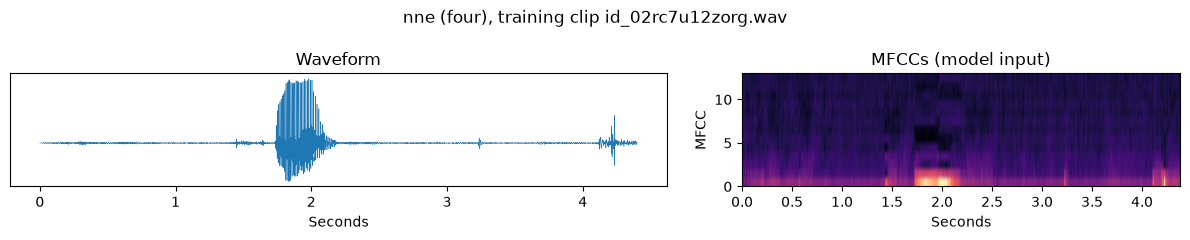

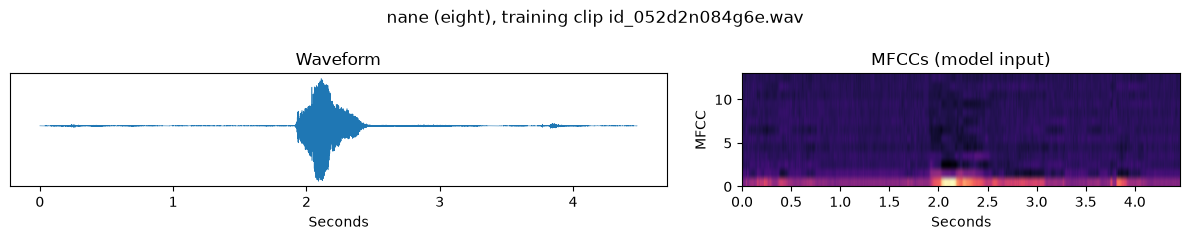

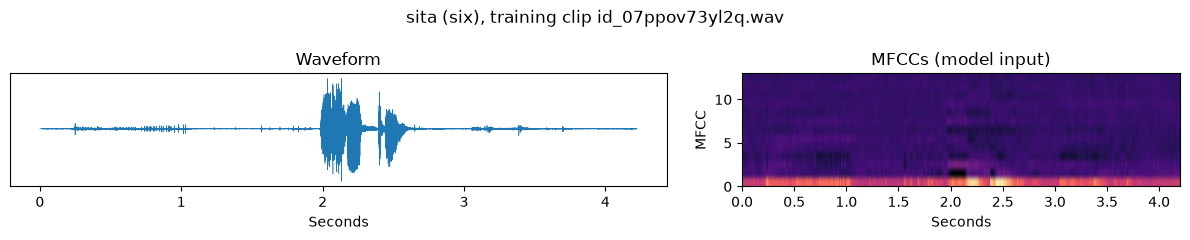

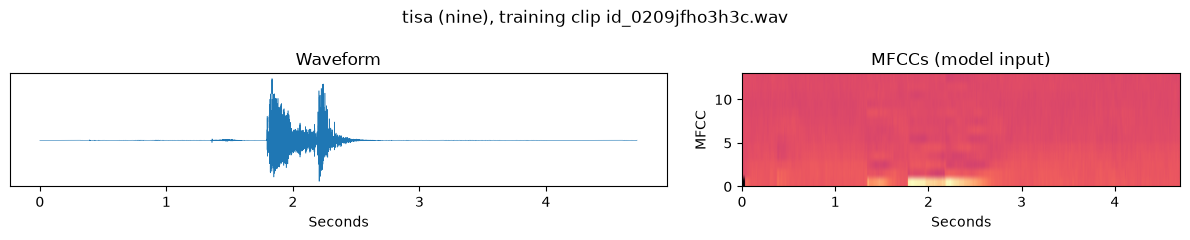

In [8]:
for word in ["nne", "nane", "sita", "tisa"]:
    example_id = data.loc[(data["split"] == "train") & (data["label"] == word), "Word_id"].iloc[0]
    show_clip(example_id, f"{word} ({english[word]}), training clip {example_id}")

## 4. Add delta and delta-delta features

The 13 MFCCs describe the sound at one moment. Deltas show how each MFCC is changing, and delta-deltas show how fast that change is changing. They help the model notice movement in the sound, like going from one syllable to the next.

13 MFCC + 13 delta + 13 delta-delta = **39 features per frame**. Each clip is still a matrix over time. Nothing is averaged.

In [9]:
delta_sequences = [with_deltas(sequence, 3) for sequence in static_sequences]

print("Before:", static_sequences[0].shape)
print("After: ", delta_sequences[0].shape)

Before: (398, 13)
After:  (398, 39)


## 5. Create the train, validation and test sets

Here I just find which rows belong to which split, and turn the 12 words into numbers from 0 to 11.

In [10]:
# Row positions of each split inside `data`
train_index = np.flatnonzero(data["split"] == "train")
val_index = np.flatnonzero(data["split"] == "validation")
test_index = np.flatnonzero(data["split"] == "test")

y_all = data["label"].map(label_to_index).to_numpy()
y_train = y_all[train_index]
y_val = y_all[val_index]
y_test = y_all[test_index]

train_with_deltas = [delta_sequences[i] for i in train_index]
val_with_deltas = [delta_sequences[i] for i in val_index]
test_with_deltas = [delta_sequences[i] for i in test_index]

print("Train / validation / test:", len(train_index), len(val_index), len(test_index))

Train / validation / test: 2940 630 630


## 6. Standardise using the training data only

Each of the 39 features gets its own mean and standard deviation, so that no feature dominates just because its values are bigger. I calculate these from the **training frames only**, then use the same numbers on validation and test.

If I used validation or test clips to calculate the mean and standard deviation, some information about them would leak into training, and the scores would look a bit better than they really are. In real use we wouldn't have the test audio in advance either.

In [11]:
# Fit on TRAIN ONLY
feature_mean, feature_std = fit_frame_standardizer(train_with_deltas)

# Apply the training statistics to all three splits
train_standardized = standardize(train_with_deltas, feature_mean, feature_std)
val_standardized = standardize(val_with_deltas, feature_mean, feature_std)
test_standardized = standardize(test_with_deltas, feature_mean, feature_std)

# Quick sanity check: train frames should now be roughly mean 0, std 1
train_frames = np.concatenate(train_standardized)
print("Train frames after standardization: mean %.3f, std %.3f" % (train_frames.mean(), train_frames.std()))
del train_frames

Train frames after standardization: mean 0.000, std 1.000


## 7. Stack three frames

I put every 3 frames side by side to make one timestep: 39 × 3 = 117 features, about 30 ms of audio per step. Each step then covers a bit more sound, and the sequence becomes 3 times shorter. This matters for a Transformer, because the cost of attention grows with the square of the sequence length.

I standardise first and stack after (same order as Person 2), so the three parts of each step use the same feature statistics.

In [12]:
FRAME_STACK = 3
train_sequences = [stack_frames(s, FRAME_STACK) for s in train_standardized]
val_sequences = [stack_frames(s, FRAME_STACK) for s in val_standardized]
test_sequences = [stack_frames(s, FRAME_STACK) for s in test_standardized]

print("Example final sequence shape:", train_sequences[0].shape)

Example final sequence shape: (133, 117)


## 8. Check the final input

```text
Audio (16 kHz, max 8 s)
  ↓
13 MFCC per 10 ms frame
  ↓
+ delta, + delta-delta  ->  39 features / frame
  ↓
standardise (training statistics)
  ↓
stack 3 frames          ->  117 features / timestep
  ↓
Transformer Encoder
```

So the Transformer gets a **sequence** of timesteps, not one fixed vector per clip. The number of timesteps changes from clip to clip because the recordings have different lengths. The table and histogram below show this: the median clip has 144 steps (about 4.3 s), and the longest ones reach the 8 s limit (266 steps).

In [13]:
for i in train_index[:3]:
    print(data.loc[i, "Word_id"], f"({data.loc[i, 'label']})")
    print("  Original MFCC shape:      ", static_sequences[i].shape)
    print("  With deltas shape:        ", delta_sequences[i].shape)
    print("  After frame stacking shape:", stack_frames(delta_sequences[i], FRAME_STACK).shape)

assert all(s.shape[1] == 117 for s in train_sequences + val_sequences + test_sequences)

id_00cn4kcmk98r.wav (moja)
  Original MFCC shape:       (398, 13)
  With deltas shape:         (398, 39)
  After frame stacking shape: (133, 117)
id_015rhcvf0g0y.wav (mbili)
  Original MFCC shape:       (366, 13)
  With deltas shape:         (366, 39)
  After frame stacking shape: (122, 117)
id_01dntd19l4a8.wav (mbili)
  Original MFCC shape:       (438, 13)
  With deltas shape:         (438, 39)
  After frame stacking shape: (146, 117)


Timesteps per clip after stacking (8 s max -> about 267 steps):


,min,median,max
train,82.0,144.0,266.0
validation,90.0,144.0,266.0
test,88.0,144.0,266.0


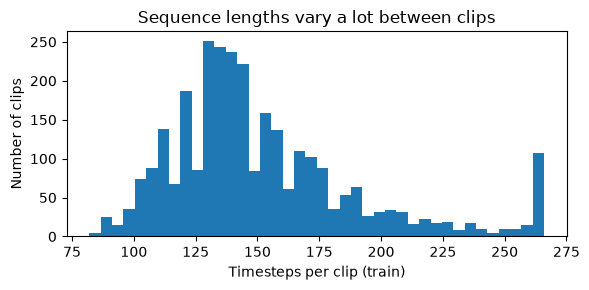

In [14]:
length_summary = pd.DataFrame({
    name: pd.Series([len(s) for s in sequences]).describe()[["min", "50%", "max"]]
    for name, sequences in [("train", train_sequences), ("validation", val_sequences), ("test", test_sequences)]
}).T.rename(columns={"50%": "median"})
print("Timesteps per clip after stacking (8 s max -> about 267 steps):")
display(length_summary)

plt.figure(figsize=(6, 3))
plt.hist([len(s) for s in train_sequences], bins=40)
plt.xlabel("Timesteps per clip (train)")
plt.ylabel("Number of clips")
plt.title("Sequence lengths vary a lot between clips")
plt.tight_layout()
plt.show()

## 9. Transformer configuration

This is how the model in `src/models/transformer.py` works:

```text
117 features per timestep
  -> Linear projection (117 -> d_model)
  -> Sinusoidal positional encoding
  -> Transformer Encoder (padding positions masked out)
  -> Masked mean pooling (only real timesteps are averaged)
  -> Dropout -> Linear head -> 12 classes
```

Self-attention on its own doesn't know the order of the frames, so I add a sinusoidal positional encoding that tells the model where each step is (Vaswani et al., 2017). At the end, I average over the real timesteps only (not the padding) to get one vector per clip, and a linear layer turns it into a score for each of the 12 words.

In [15]:
baseline_config = TransformerConfig(
    name="transformer_baseline",
    d_model=128,
    nhead=4,
    num_layers=2,
    dim_feedforward=256,
    dropout=0.2,
    learning_rate=1e-3,
    weight_decay=1e-4,
    batch_size=32,
    max_epochs=30,
    patience=8,
    grad_clip=1.0,
)

n_features = train_sequences[0].shape[1]
baseline_model = TransformerClassifier(n_features, n_classes, baseline_config)
n_trainable = sum(p.numel() for p in baseline_model.parameters() if p.requires_grad)

print(baseline_config)
print(f"\nInput features: {n_features} | classes: {n_classes}")
print(f"Trainable parameters: {n_trainable:,}")

TransformerConfig(name='transformer_baseline', d_model=128, nhead=4, num_layers=2, dim_feedforward=256, dropout=0.2, learning_rate=0.001, weight_decay=0.0001, batch_size=32, max_epochs=30, patience=8, grad_clip=1.0)

Input features: 117 | classes: 12
Trainable parameters: 281,612


## 10. Test the model before training

Before training, I check on a small batch that:

1. clips of different lengths can be padded into one batch,
2. the model gives one score per word, so the output has shape `(batch_size, 12)`,
3. the padding is really ignored. To test this, I add 20 extra padding steps filled with the value 5 instead of zeros. If the masking works, the output should not change at all.

In [16]:
set_torch_seed(SEED)
smoke_model = TransformerClassifier(n_features, n_classes, baseline_config).eval()

examples = [torch.from_numpy(train_sequences[i]) for i in range(4)]
lengths = torch.tensor([len(x) for x in examples])
batch = pad_sequence(examples, batch_first=True)        # pads with zeros up to the longest clip

print("Lengths in this batch:", lengths.tolist())
print("Padded batch shape:   ", tuple(batch.shape))

# This is the same rule the model uses internally: True = padding, ignored
padding_mask = torch.arange(batch.shape[1])[None, :] >= lengths[:, None]
print("Padded steps per clip:", padding_mask.sum(dim=1).tolist())

with torch.no_grad():
    logits = smoke_model(batch, lengths)

    junk = torch.full((batch.shape[0], 20, batch.shape[2]), 5.0)
    logits_extra_padding = smoke_model(torch.cat([batch, junk], dim=1), lengths)

print("Logits shape:", tuple(logits.shape))
print("Max change after adding junk padding:", (logits - logits_extra_padding).abs().max().item())

assert logits.shape == (4, n_classes)
assert torch.allclose(logits, logits_extra_padding, atol=1e-5), "Padding is leaking into the output!"
print("Smoke test passed.")

Lengths in this batch: [133, 122, 146, 117]
Padded batch shape:    (4, 146, 117)
Padded steps per clip: [13, 24, 0, 29]
Logits shape: (4, 12)
Max change after adding junk padding: 0.0
Smoke test passed.


## 11. Baseline training

First I train the baseline model on its own. I wrote two small helper functions so that the experiment cells stay short:

- `run_experiment` trains one setup using **only the train and validation splits**. It stops early when validation macro-F1 hasn't improved for 8 epochs, and it keeps the weights from the best epoch. The test split is never passed in.
- `plot_learning_curves` plots the loss and score curves of one run.

In [17]:
experiment_configs = []
results = {}


def plot_learning_curves(config, result):
    """Loss and score curves for one experiment. Dashed line = epoch whose weights were kept."""
    history = result.history

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

    axes[0].plot(history["epoch"], history["train_loss"], label="train loss")
    axes[0].plot(history["epoch"], history["val_loss"], label="validation loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-entropy loss")
    axes[0].legend()

    axes[1].plot(history["epoch"], history["train_accuracy"], label="train accuracy", alpha=0.6)
    axes[1].plot(history["epoch"], history["val_macro_f1"], label="validation macro-F1")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Score")
    axes[1].legend()

    for ax in axes:
        ax.axvline(result.best_epoch, color="grey", linestyle="--", linewidth=1)

    fig.suptitle(f"{config.name}: best validation macro-F1 {result.best_val_metrics['macro_f1']:.4f} "
                 f"at epoch {result.best_epoch} ({len(history)} of {config.max_epochs} epochs run)")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"learning_curves_{config.name}.png", dpi=150)
    plt.show()


def run_experiment(config):
    """Train one configuration on train/validation only and save its history."""
    print(f"=== {config.name} ===")
    result = train_transformer(
        config,
        train_sequences, y_train,
        val_sequences, y_val,
        n_classes=n_classes,
        seed=SEED,
        device=device,
    )
    if config not in experiment_configs:      # re-running a cell does not add it twice
        experiment_configs.append(config)
    results[config.name] = result
    result.history.to_csv(OUTPUT_DIR / "histories" / f"{config.name}.csv", index=False)
    print(f"Best val macro-F1 {result.best_val_metrics['macro_f1']:.4f} at epoch {result.best_epoch} "
          f"({result.seconds:.0f} s)")
    return result

In [18]:
config_a = baseline_config
result_a = run_experiment(config_a)

=== transformer_baseline ===
  [transformer_baseline seed=42] epoch   1 train_loss=1.818 val_loss=0.849 val_macro_f1=0.726 (best 0.726 @ 1)
  [transformer_baseline seed=42] epoch   5 train_loss=0.141 val_loss=0.315 val_macro_f1=0.922 (best 0.925 @ 4)
  [transformer_baseline seed=42] epoch  10 train_loss=0.069 val_loss=0.316 val_macro_f1=0.932 (best 0.935 @ 9)
  [transformer_baseline seed=42] epoch  15 train_loss=0.014 val_loss=0.344 val_macro_f1=0.946 (best 0.946 @ 15)
  [transformer_baseline seed=42] epoch  20 train_loss=0.001 val_loss=0.308 val_macro_f1=0.948 (best 0.948 @ 20)
  [transformer_baseline seed=42] epoch  25 train_loss=0.000 val_loss=0.292 val_macro_f1=0.948 (best 0.948 @ 25)
  [transformer_baseline seed=42] epoch  30 train_loss=0.000 val_loss=0.289 val_macro_f1=0.945 (best 0.948 @ 25)
Best val macro-F1 0.9479 at epoch 25 (113 s)


## 12. Baseline training curves

Left: training and validation loss. Right: training accuracy and validation macro-F1. The dashed line is the epoch whose weights were kept.

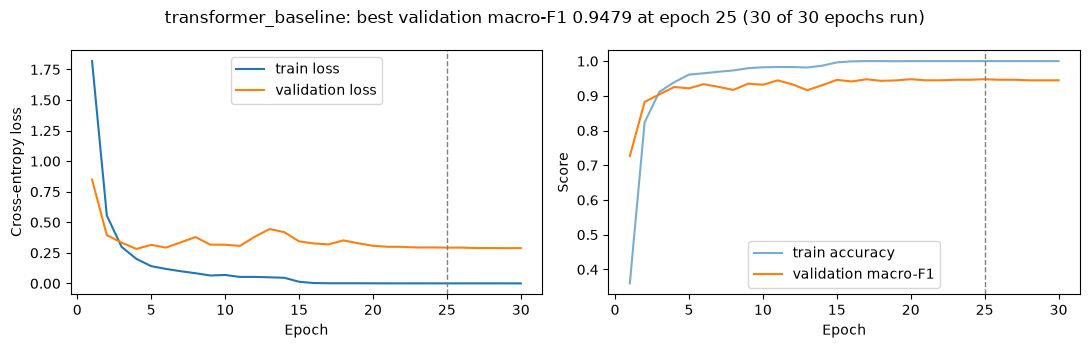

In [19]:
plot_learning_curves(config_a, result_a)

## 13. Validation experiments

I didn't do a big search. I tried a few changes around the baseline (A, trained above), and each one changes only **one** thing:

| Experiment | What changes | Why |
|---|---|---|
| A, baseline | d_model 128, 4 heads, 2 layers, dropout 0.2 | starting point |
| B, smaller | d_model 64 | with only 2,940 training clips, a smaller model might be enough |
| C, deeper | 3 encoder layers | to see if one more attention layer learns better features |
| D, more dropout | dropout 0.4 | to see if the baseline is overfitting |

Everything else (feed-forward size 256, learning rate, batch size and so on) is the same for all four.

### Experiment B: smaller model (d_model 64)

With only 2,940 training clips, a model with fewer parameters might do just as well, or even better.

=== smaller_d_model_64 ===
  [smaller_d_model_64 seed=42] epoch   1 train_loss=2.309 val_loss=1.584 val_macro_f1=0.383 (best 0.383 @ 1)
  [smaller_d_model_64 seed=42] epoch   5 train_loss=0.246 val_loss=0.394 val_macro_f1=0.891 (best 0.891 @ 5)
  [smaller_d_model_64 seed=42] epoch  10 train_loss=0.085 val_loss=0.483 val_macro_f1=0.908 (best 0.926 @ 9)
  [smaller_d_model_64 seed=42] epoch  15 train_loss=0.018 val_loss=0.440 val_macro_f1=0.937 (best 0.937 @ 15)
  [smaller_d_model_64 seed=42] epoch  20 train_loss=0.004 val_loss=0.494 val_macro_f1=0.929 (best 0.937 @ 15)
Best val macro-F1 0.9366 at epoch 15 (84 s)


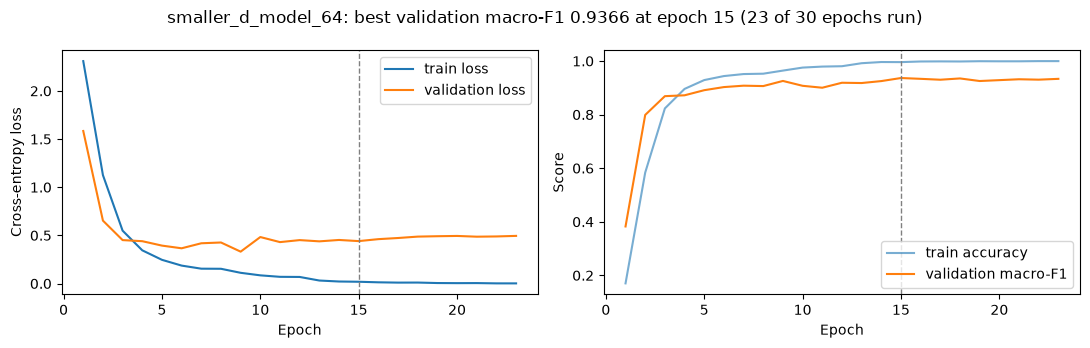

In [20]:
config_b = replace(baseline_config, name="smaller_d_model_64", d_model=64)
result_b = run_experiment(config_b)
plot_learning_curves(config_b, result_b)

### Experiment C: deeper model (3 encoder layers)

Does one more attention layer help the model build better features from the frames?

=== deeper_3_layers ===
  [deeper_3_layers seed=42] epoch   1 train_loss=1.816 val_loss=0.868 val_macro_f1=0.713 (best 0.713 @ 1)
  [deeper_3_layers seed=42] epoch   5 train_loss=0.184 val_loss=0.498 val_macro_f1=0.879 (best 0.899 @ 4)
  [deeper_3_layers seed=42] epoch  10 train_loss=0.068 val_loss=0.432 val_macro_f1=0.919 (best 0.926 @ 8)
  [deeper_3_layers seed=42] epoch  15 train_loss=0.017 val_loss=0.311 val_macro_f1=0.948 (best 0.948 @ 15)
  [deeper_3_layers seed=42] epoch  20 train_loss=0.001 val_loss=0.292 val_macro_f1=0.959 (best 0.959 @ 20)
  [deeper_3_layers seed=42] epoch  25 train_loss=0.001 val_loss=0.284 val_macro_f1=0.954 (best 0.959 @ 20)
Best val macro-F1 0.9587 at epoch 20 (145 s)


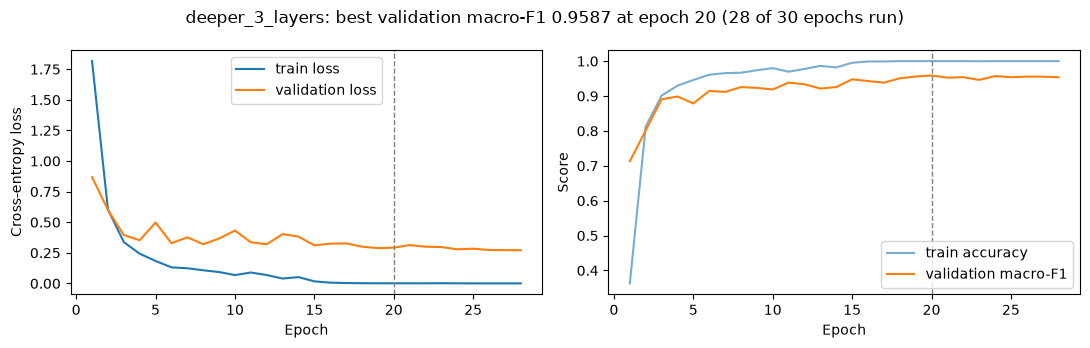

In [21]:
config_c = replace(baseline_config, name="deeper_3_layers", num_layers=3)
result_c = run_experiment(config_c)
plot_learning_curves(config_c, result_c)

### Experiment D: more dropout (0.4)

If the baseline's training score pulls away from its validation score, more dropout should make that gap smaller.

=== dropout_0.4 ===
  [dropout_0.4 seed=42] epoch   1 train_loss=2.008 val_loss=0.938 val_macro_f1=0.682 (best 0.682 @ 1)
  [dropout_0.4 seed=42] epoch   5 train_loss=0.224 val_loss=0.293 val_macro_f1=0.922 (best 0.922 @ 5)
  [dropout_0.4 seed=42] epoch  10 train_loss=0.056 val_loss=0.280 val_macro_f1=0.940 (best 0.940 @ 6)
  [dropout_0.4 seed=42] epoch  15 train_loss=0.004 val_loss=0.306 val_macro_f1=0.956 (best 0.956 @ 15)
  [dropout_0.4 seed=42] epoch  20 train_loss=0.002 val_loss=0.327 val_macro_f1=0.946 (best 0.956 @ 17)
  [dropout_0.4 seed=42] epoch  25 train_loss=0.001 val_loss=0.314 val_macro_f1=0.949 (best 0.956 @ 17)
Best val macro-F1 0.9557 at epoch 17 (92 s)


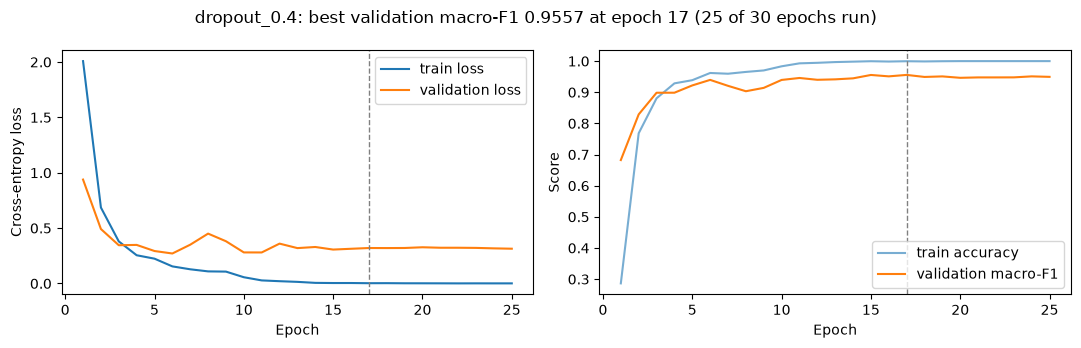

In [22]:
config_d = replace(baseline_config, name="dropout_0.4", dropout=0.4)
result_d = run_experiment(config_d)
plot_learning_curves(config_d, result_d)

### Comparing the four experiments

All the numbers and plots here come from the **validation split only**.

In [23]:
rows = []
for config in experiment_configs:
    result = results[config.name]
    rows.append({
        "experiment": config.name,
        "d_model": config.d_model,
        "nhead": config.nhead,
        "num_layers": config.num_layers,
        "dropout": config.dropout,
        "best_epoch": result.best_epoch,
        "epochs_run": len(result.history),
        "val_accuracy": result.best_val_metrics["accuracy"],
        "val_macro_f1": result.best_val_metrics["macro_f1"],
        "train_seconds": round(result.seconds, 1),
        "n_parameters": result.n_parameters,
    })

validation_table = pd.DataFrame(rows).sort_values("val_macro_f1", ascending=False).reset_index(drop=True)
validation_table.to_csv(OUTPUT_DIR / "validation_experiments.csv", index=False)
validation_table.round(4)

,experiment,d_model,nhead,num_layers,dropout,best_epoch,epochs_run,val_accuracy,val_macro_f1,train_seconds,n_parameters
0,deeper_3_layers,128,4,3,0.2,20,28,0.9587,0.9587,145.4,414092
1,dropout_0.4,128,4,2,0.4,17,25,0.9556,0.9557,91.9,281612
2,transformer_baseline,128,4,2,0.2,25,30,0.9476,0.9479,113.3,281612
3,smaller_d_model_64,64,4,2,0.2,15,23,0.9365,0.9366,84.2,108300


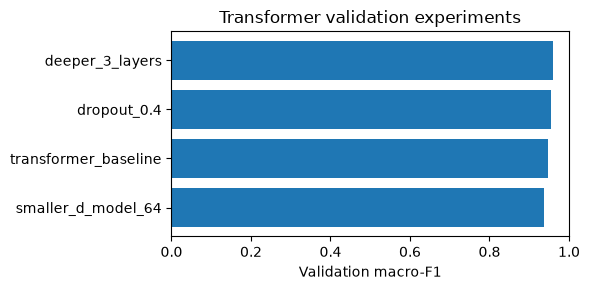

In [24]:
plt.figure(figsize=(6, 3))
plt.barh(validation_table["experiment"][::-1], validation_table["val_macro_f1"][::-1])
plt.xlabel("Validation macro-F1")
plt.xlim(0, 1)
plt.title("Transformer validation experiments")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "validation_experiments.png", dpi=150)
plt.show()

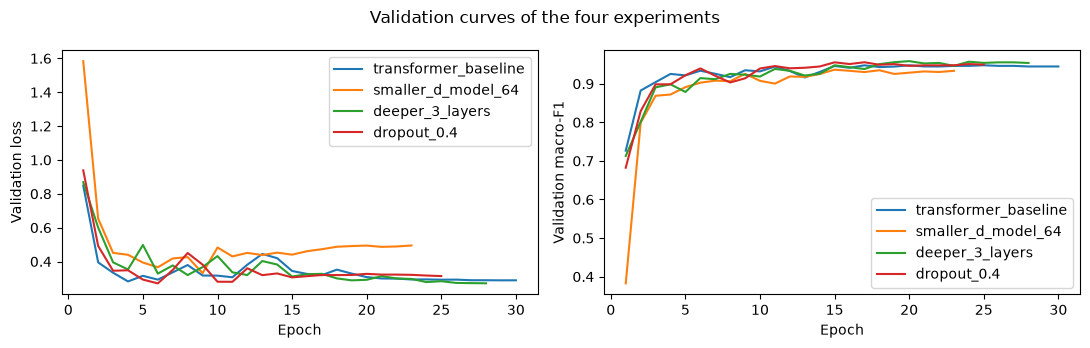

In [25]:
# All four experiments on one plot, to compare how fast and how far each one gets on validation
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for config in experiment_configs:
    history = results[config.name].history
    axes[0].plot(history["epoch"], history["val_loss"], label=config.name)
    axes[1].plot(history["epoch"], history["val_macro_f1"], label=config.name)

axes[0].set_ylabel("Validation loss")
axes[1].set_ylabel("Validation macro-F1")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.legend()
fig.suptitle("Validation curves of the four experiments")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "validation_curves_all_experiments.png", dpi=150)
plt.show()

## 14. Select the best configuration

My rule is simple: the configuration with the **highest validation macro-F1** wins. The test set is not used for this.

In [26]:
best_name = validation_table.loc[0, "experiment"]
best_config = next(c for c in experiment_configs if c.name == best_name)
best_result = results[best_name]
best_model = best_result.model

print("Best configuration:", best_name)
print(best_config)
print(f"Validation macro-F1: {best_result.best_val_metrics['macro_f1']:.4f} (epoch {best_result.best_epoch})")

Best configuration: deeper_3_layers
TransformerConfig(name='deeper_3_layers', d_model=128, nhead=4, num_layers=3, dim_feedforward=256, dropout=0.2, learning_rate=0.001, weight_decay=0.0001, batch_size=32, max_epochs=30, patience=8, grad_clip=1.0)
Validation macro-F1: 0.9587 (epoch 20)


## 15. Lock the model

From here on, the setup is **locked**. I save the choice to `selected_config.json` *before* looking at the test set, and I won't change the model or retrain it because of anything I see in the test results.

In [27]:
(OUTPUT_DIR / "selected_config.json").write_text(json.dumps({
    "selected": best_config.to_dict(),
    "front_end": preprocessing.to_dict(),
    "feature_streams": 3,
    "frame_stack": FRAME_STACK,
    "n_features": n_features,
    "selection_rule": "Highest validation macro-F1 among the four validation experiments.",
    "selected_val_macro_f1": best_result.best_val_metrics["macro_f1"],
    "best_epoch": best_result.best_epoch,
}, indent=2))
print("Locked:", best_name)

Locked: deeper_3_layers


## 16. Internal test evaluation

This is the **first time I use the test split**. I evaluate the locked model once, using the group's shared metric function in `src/evaluation/metrics.py`.

**Why these metrics**

- **Macro-F1** is my main metric. It calculates the F1 score for each word separately and then takes the average, so every word counts the same. Our classes are balanced (about 52 test clips per word), so accuracy gives almost the same number, but macro-F1 would still be fair if one word was much easier than the rest. The other group models report it too, so we can compare.
- **Accuracy** is the easiest to understand: the share of clips the model got right.
- **Macro precision and recall** show whether the mistakes come more from predicting a word wrongly (precision) or from missing it (recall).
- **Macro ROC-AUC** uses the predicted probabilities, not just the top answer. It shows how well the model ranks the right word above the wrong ones.

I show validation next to test so the gap between them is easy to see.

In [28]:
test_proba = predict_proba(best_model, test_sequences, device)
test_pred = test_proba.argmax(axis=1)

test_metrics = classification_metrics(y_test, test_pred, test_proba)

# Validation metrics of the same locked model, just for reference next to the test numbers
val_proba = predict_proba(best_model, val_sequences, device)
val_metrics = classification_metrics(y_val, val_proba.argmax(axis=1), val_proba)

pd.DataFrame({"validation": val_metrics, "test": test_metrics}).round(4)

,validation,test
accuracy,0.9587,0.9286
macro_f1,0.9587,0.9285
weighted_f1,0.9586,0.9286
macro_precision,0.9592,0.9295
macro_recall,0.9588,0.9285
macro_roc_auc,0.9968,0.9969


## 17. Classification report

This table shows precision, recall and F1 for each word on the test set, sorted from best to worst F1. Precision answers "when the model says this word, how often is it right?". Recall answers "of all the clips of this word, how many did the model get?". Support is the number of test clips of that word.

In [29]:
report = classification_report_frame(y_test, test_pred, class_names, "transformer", "test")
per_class = report[report["class"].isin(class_names)].copy()
per_class["english"] = per_class["class"].map(english)
per_class = per_class.sort_values("f1-score", ascending=False)

display(per_class[["class", "english", "precision", "recall", "f1-score", "support"]].round(3))

print("Strongest classes:", ", ".join(per_class["class"].head(3)))
print("Weakest classes:  ", ", ".join(per_class["class"].tail(3)))

,class,english,precision,recall,f1-score,support
7,saba,seven,0.981,0.981,0.981,53.0
11,tisa,nine,1.000,0.962,0.981,53.0
10,tatu,three,0.911,0.981,0.944,52.0
5,ndio,yes,0.960,0.923,0.941,52.0
3,moja,one,0.926,0.943,0.935,53.0
4,nane,eight,0.909,0.943,0.926,53.0
8,sita,six,0.940,0.904,0.922,52.0
0,hapana,no,0.922,0.904,0.913,52.0
1,kumi,ten,0.891,0.925,0.907,53.0
9,tano,five,0.938,0.865,0.900,52.0


Strongest classes: saba, tisa, tatu
Weakest classes:   tano, mbili, nne


## 18. Confusion matrix and ROC curves

Each row is the true word and each column is the predicted word. The diagonal shows the correct answers. Anything off the diagonal is a mistake.

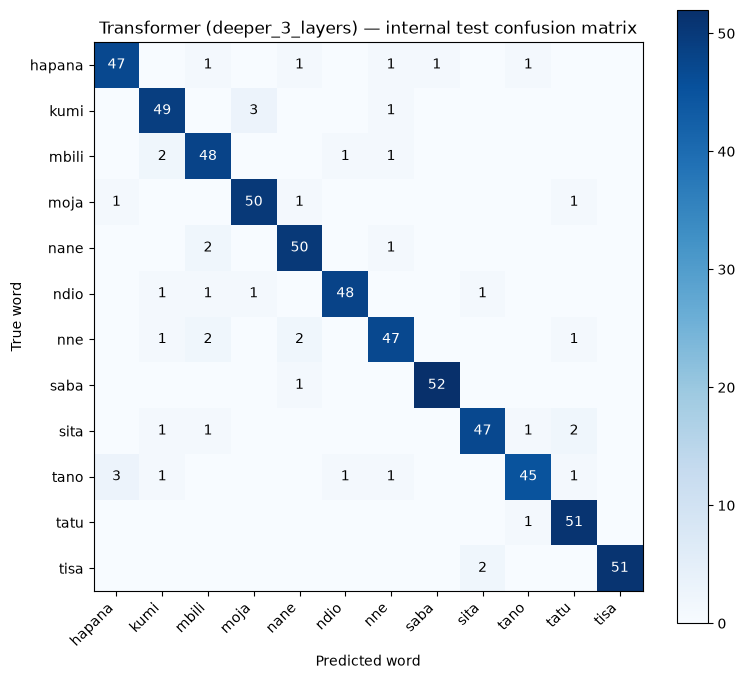

In [30]:
test_confusion = confusion_frame(y_test, test_pred, class_names)

fig, ax = plt.subplots(figsize=(8, 7))
image = ax.imshow(test_confusion.to_numpy(), cmap="Blues")
fig.colorbar(image, ax=ax)

ax.set_xticks(range(n_classes))
ax.set_yticks(range(n_classes))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

threshold = test_confusion.to_numpy().max() / 2
for row in range(n_classes):
    for col in range(n_classes):
        value = test_confusion.iloc[row, col]
        if value > 0:
            ax.text(col, row, value, ha="center", va="center",
                    color="white" if value > threshold else "black")

ax.set_xlabel("Predicted word")
ax.set_ylabel("True word")
ax.set_title(f"Transformer ({best_name}) — internal test confusion matrix")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "test_confusion_matrix.png", dpi=150)
plt.show()

### ROC curves (one-vs-rest)

The confusion matrix only looks at the model's top answer. ROC curves use the full probabilities instead. For each word, I treat it as "this word vs. all the others" and check how well the model's probability for that word separates the two groups, at every possible threshold.

- If the curve goes straight up the left side and along the top (AUC = 1), the word is separated perfectly.
- The dashed diagonal (AUC = 0.5) is random guessing.

The right plot zooms into the top-left corner, because with AUCs this high the curves are hard to tell apart in the full plot. The average of the per-word AUCs should be the same as the `macro_roc_auc` in section 16.

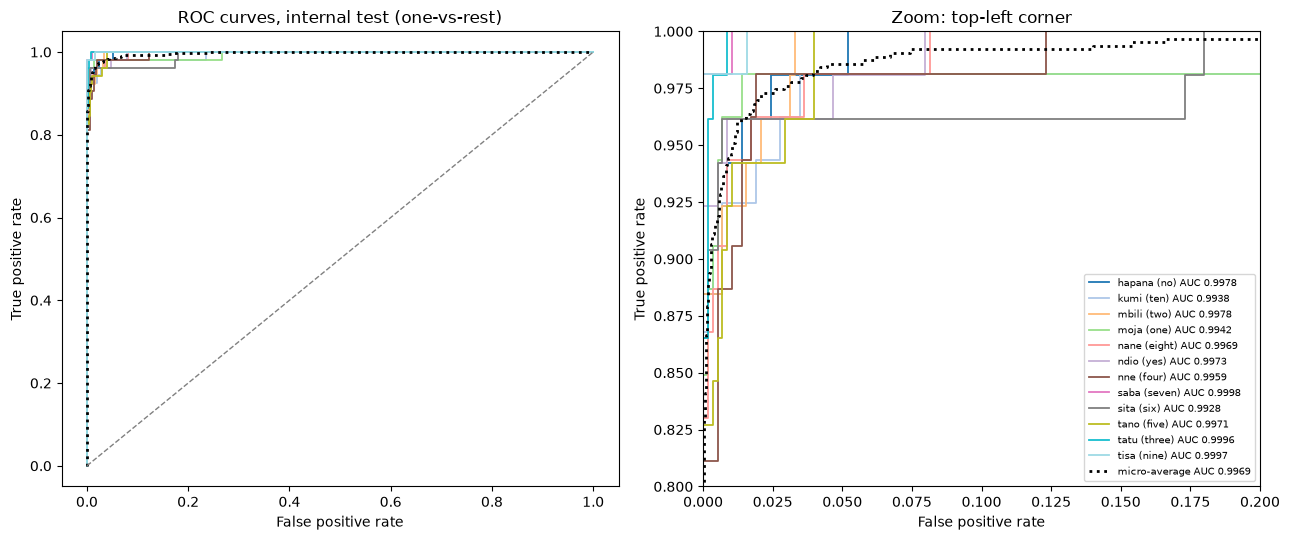

Mean of per-word AUCs: 0.9969 (macro_roc_auc from section 16: 0.9969)


,roc_auc,english
sita,0.9928,six
kumi,0.9938,ten
moja,0.9942,one
nne,0.9959,four
nane,0.9969,eight
tano,0.9971,five
ndio,0.9973,yes
mbili,0.9978,two
hapana,0.9978,no
tatu,0.9996,three


In [31]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# One column per word: 1 if the clip is that word, 0 otherwise
y_test_onehot = label_binarize(y_test, classes=np.arange(n_classes))

per_class_auc = {}
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
colors = plt.cm.tab20(np.linspace(0, 1, n_classes))

for i, word in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_onehot[:, i], test_proba[:, i])
    per_class_auc[word] = auc(fpr, tpr)
    for ax in axes:
        ax.plot(fpr, tpr, color=colors[i], linewidth=1.3,
                label=f"{word} ({english[word]}) AUC {per_class_auc[word]:.4f}")

# Micro-average: every (clip, word) pair pooled together
fpr_micro, tpr_micro, _ = roc_curve(y_test_onehot.ravel(), test_proba.ravel())
for ax in axes:
    ax.plot(fpr_micro, tpr_micro, color="black", linestyle=":", linewidth=2,
            label=f"micro-average AUC {auc(fpr_micro, tpr_micro):.4f}")
    ax.plot([0, 1], [0, 1], color="grey", linestyle="--", linewidth=1)
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")

axes[0].set_title("ROC curves, internal test (one-vs-rest)")
axes[1].set_xlim(0, 0.2)
axes[1].set_ylim(0.8, 1.0)
axes[1].set_title("Zoom: top-left corner")
axes[1].legend(fontsize=7.5, loc="lower right")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "test_roc_curves.png", dpi=150)
plt.show()

auc_table = pd.Series(per_class_auc, name="roc_auc").sort_values().to_frame()
auc_table["english"] = auc_table.index.map(english)
print(f"Mean of per-word AUCs: {auc_table['roc_auc'].mean():.4f} "
      f"(macro_roc_auc from section 16: {test_metrics['macro_roc_auc']:.4f})")
auc_table.round(4)

## 19. Error analysis

First: which mistakes happen most often, and how confident was the model when it was wrong?

In [32]:
pairs = []
for true_word in class_names:
    for predicted_word in class_names:
        count = test_confusion.loc[true_word, predicted_word]
        if true_word != predicted_word and count > 0:
            pairs.append({
                "true_word": true_word,
                "predicted_word": predicted_word,
                "true_english": english[true_word],
                "predicted_english": english[predicted_word],
                "errors": int(count),
            })

error_pairs = pd.DataFrame(pairs, columns=["true_word", "predicted_word", "true_english",
                                           "predicted_english", "errors"])
error_pairs = error_pairs.sort_values("errors", ascending=False).reset_index(drop=True)

print(f"Total test errors: {int((test_pred != y_test).sum())} out of {len(y_test)}")
for _, row in error_pairs.head(10).iterrows():
    print(f"  {row.true_word} -> {row.predicted_word} : {row.errors}")

Total test errors: 45 out of 630
  tano -> hapana : 3
  kumi -> moja : 3
  mbili -> kumi : 2
  nne -> nane : 2
  nane -> mbili : 2
  sita -> tatu : 2
  tisa -> sita : 2
  nne -> mbili : 2
  tano -> ndio : 1
  tano -> kumi : 1


In [33]:
# How confident was the model when it was wrong vs right?
test_predictions = data.iloc[test_index][["Word_id", "label"]].reset_index(drop=True)
test_predictions["predicted"] = [class_names[i] for i in test_pred]
test_predictions["correct"] = test_predictions["label"] == test_predictions["predicted"]
test_predictions["confidence"] = test_proba.max(axis=1)
test_predictions["n_timesteps"] = [len(s) for s in test_sequences]

test_predictions.groupby("correct")[["confidence", "n_timesteps"]].median()

,confidence,n_timesteps
correct,,
False,0.884802,152.0
True,0.999999,144.0


### What is different about the wrong clips?

The tables above only use the model's outputs. Now I look at the recordings themselves and compare the 45 wrong test clips with the 585 correct ones, using:

- **duration** of the full recording (before the 8 s cut),
- **loudness** (RMS amplitude),
- **near-silence**: the share of samples quieter than 1% of the clip's own peak (the same rule the group used in the EDA).

In [34]:
from src.data.audio import collect_metadata
from src.data.loading import audio_zip_path

audio_stats = test_predictions.merge(
    collect_metadata(test_predictions["Word_id"].tolist(), audio_zip_path(), progress_every=0),
    on="Word_id",
)
audio_stats["longer_than_cut"] = audio_stats["duration_seconds"] > preprocessing.duration_seconds


def errors_by(column):
    table = audio_stats.groupby(column, observed=True).agg(
        clips=("correct", "size"), errors=("correct", lambda s: int((~s).sum())))
    table["error_rate"] = (table["errors"] / table["clips"]).round(3)
    return table


print("Median audio properties (wrong vs correct):")
display(audio_stats.groupby("correct")[["duration_seconds", "rms_amplitude", "low_energy_proportion"]]
        .median().round(3))

print(f"Errors by length (every clip is cut at {preprocessing.duration_seconds:.0f} s):")
display(errors_by("longer_than_cut").rename(index={False: "8 s or shorter", True: "longer than 8 s"}))

audio_stats["loudness_quarter"] = pd.qcut(audio_stats["rms_amplitude"], 4,
                                          labels=["quietest", "2nd", "3rd", "loudest"])
print("Errors by loudness (quarters of the test clips):")
display(errors_by("loudness_quarter"))

Read audio metadata 630/630
Median audio properties (wrong vs correct):


,duration_seconds,rms_amplitude,low_energy_proportion
correct,,,
False,4.56,688.662,0.582
True,4.32,873.966,0.849


Errors by length (every clip is cut at 8 s):


,clips,errors,error_rate
longer_than_cut,,,
8 s or shorter,604,35,0.058
longer than 8 s,26,10,0.385


Errors by loudness (quarters of the test clips):


,clips,errors,error_rate
loudness_quarter,,,
quietest,158,15,0.095
2nd,157,13,0.083
3rd,157,10,0.064
loudest,158,7,0.044


Long clips are cut at 8 s and only the start is kept, so the word itself might get cut off. To check this without listening to every clip, I find the loudest half-second in each long recording. If it comes after the 8 s cut, the model probably didn't get the spoken word.

In [35]:
def loudest_moment(word_id, window_seconds=0.5):
    """Centre (in seconds) of the loudest half-second of the full recording."""
    clip = load_audio(word_id, preprocessing)
    window = int(window_seconds * clip.sample_rate)
    energy = np.concatenate([[0.0], np.cumsum(clip.samples ** 2)])
    window_energy = energy[window:] - energy[:-window]
    return np.argmax(window_energy) / clip.sample_rate + window_seconds / 2


long_clips = audio_stats[audio_stats["longer_than_cut"]].copy()
long_clips["loudest_at_s"] = long_clips["Word_id"].map(loudest_moment)
long_clips["loudest_after_cut"] = long_clips["loudest_at_s"] > preprocessing.duration_seconds

wrong_long = long_clips[~long_clips["correct"]]
print(f"Wrong long clips whose loudest part is after the cut: "
      f"{int(wrong_long['loudest_after_cut'].sum())} of {len(wrong_long)}")
print(f"Correct long clips whose loudest part is after the cut: "
      f"{int(long_clips.loc[long_clips['correct'], 'loudest_after_cut'].sum())} of {int(long_clips['correct'].sum())}")
long_clips[["Word_id", "label", "predicted", "correct", "confidence", "duration_seconds", "loudest_at_s"]] \
    .sort_values(["correct", "duration_seconds"], ascending=[True, False]).round(2).reset_index(drop=True)

Wrong long clips whose loudest part is after the cut: 2 of 10
Correct long clips whose loudest part is after the cut: 0 of 16


,Word_id,label,predicted,correct,confidence,duration_seconds,loudest_at_s
0,id_qconko34be1q.wav,kumi,moja,False,1.00,62.21,54.45
1,id_toljkyjcpo2g.wav,nane,mbili,False,0.34,62.08,27.26
2,id_q9z5v56z1fie.wav,ndio,kumi,False,0.64,21.25,2.73
3,id_poszu5k0wknu.wav,nne,mbili,False,1.00,12.24,5.19
4,id_nkqgf0m08luw.wav,mbili,kumi,False,0.81,11.52,2.70
5,id_rysagj0hh4eo.wav,nne,nane,False,0.65,9.22,2.60
6,id_mr1a29uxppv7.wav,sita,mbili,False,0.73,8.96,5.81
7,id_woulyphxdxnb.wav,tano,tatu,False,1.00,8.80,6.90
8,id_c0ny48df29cz.wav,ndio,moja,False,0.95,8.48,4.08
9,id_weixje33tsig.wav,tano,nne,False,0.49,8.06,1.95


### Listening to the most confident mistakes

These are the 4 wrong test clips where the model was most sure about its wrong answer. Listening to them is the easiest way to understand what went wrong.

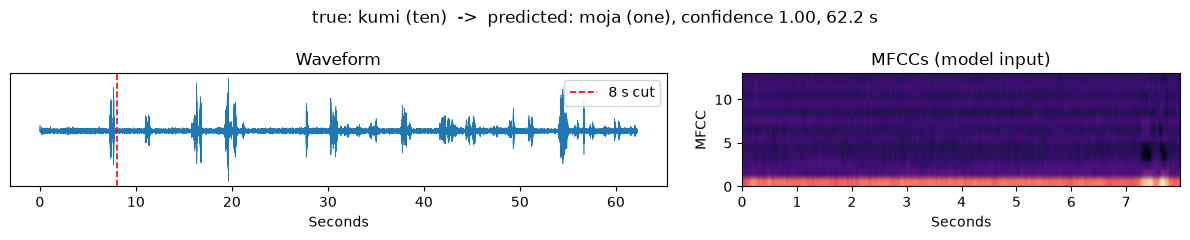

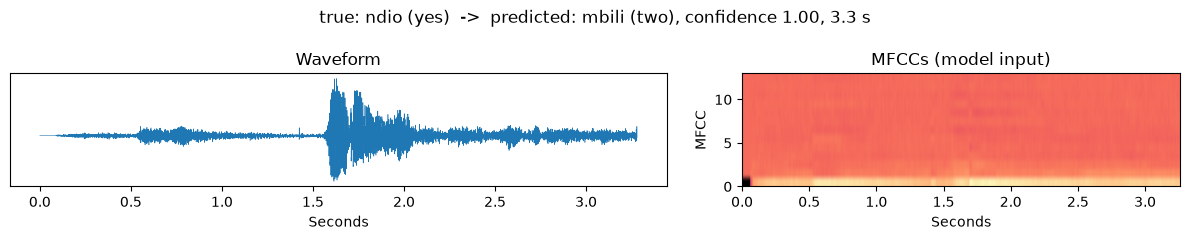

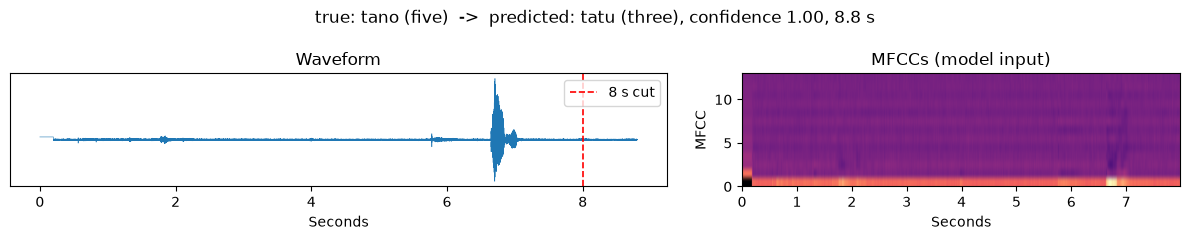

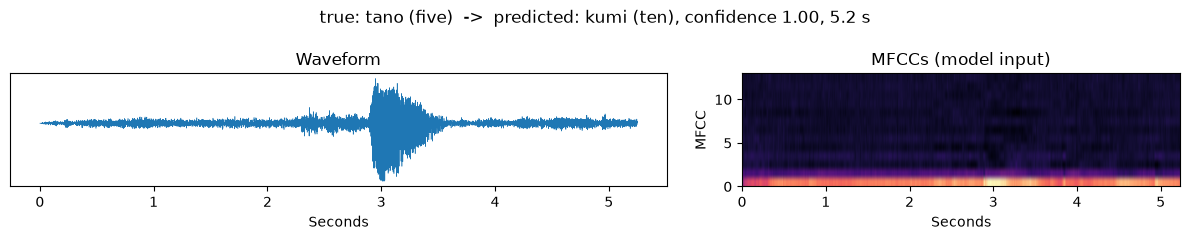

In [36]:
most_confident_errors = audio_stats[~audio_stats["correct"]].sort_values("confidence", ascending=False).head(4)

for _, row in most_confident_errors.iterrows():
    show_clip(row["Word_id"],
              f"true: {row['label']} ({english[row['label']]})  ->  predicted: {row['predicted']} "
              f"({english[row['predicted']]}), confidence {row['confidence']:.2f}, {row['duration_seconds']:.1f} s")

**What I found**

- The model gets **45 mistakes out of 630** test clips. No pair of words stands out. The most common mistakes are **tano → hapana** (five → no) and **kumi → moja** (ten → one), but each happens only 3 times, and every other pair happens 2 times or less. So the model doesn't have one big systematic problem. The errors are spread out.
- Some mistakes are between words that sound alike. The clearest is **nne → nane** (four → eight), which differ by only one vowel. **tisa → sita** (nine → six) uses the same two syllables in the opposite order, and **sita → tatu** (six → three) both have "ta". My guess is that their MFCC frames look similar for most of the clip. But some mistakes, like tano → hapana or kumi → moja, don't sound alike at all, so I can't explain those from the words.
- The weakest words by F1 are **nne (0.895), mbili (0.897) and tano (0.900)**. The best are saba and tisa (both 0.981).
- The model is less sure when it is wrong. The median confidence is **0.885 for wrong answers and 0.99999 for correct ones**. In a real app, answers with low confidence could be sent to a person to check.
- **Long recordings are the biggest audio problem.** Only 26 of the 630 test clips are longer than 8 s, but 10 of them are wrong. That is an error rate of **38.5%, compared with 5.8%** for clips of 8 s or less, so 4% of the clips cause 10 of the 45 errors. Every clip is cut at 8 s and the start is kept, so in a long recording the word can be cut off. In 2 of these 10 clips, the loudest part comes after the cut. The worst mistake of all (kumi → moja, confidence 1.00) is a 62-second recording with lots of separate bursts of sound (see its waveform under "Listening to the most confident mistakes"). The first burst starts just before the 8 s cut and the loudest one is at about 54 s, so the model saw mostly silence and only the start of one sound. In the other 8 long clips the loudest part is before the cut, so the cut doesn't explain them. I would need to listen to them to know more, which is what the players above are for.
- **Quieter recordings are a bit harder.** The quietest quarter of the test clips has 15 errors and the loudest quarter has 7. The wrong clips also have less near-silence (median 58% vs 85% of samples), which could mean more background noise around the word. This is only a hint, not a proven cause.

## 20. Final results and discussion

### 20.1 Final numbers

This cell prints the numbers I use in the discussion, so I don't have to copy them by hand.

In [37]:
print(f"Locked configuration: {best_name}")
print(f"Validation macro-F1 range across experiments: "
      f"{validation_table['val_macro_f1'].min():.4f} - {validation_table['val_macro_f1'].max():.4f}")
print(f"Internal test accuracy: {test_metrics['accuracy']:.4f}")
print(f"Internal test macro-F1: {test_metrics['macro_f1']:.4f}")
print(f"Internal test macro ROC-AUC: {test_metrics['macro_roc_auc']:.4f}")
print("Weakest classes:", ", ".join(per_class["class"].tail(3)))
print("Most common confusion:",
      f"{error_pairs.loc[0, 'true_word']} -> {error_pairs.loc[0, 'predicted_word']}" if len(error_pairs) else "none")

# Validation results per run, with the number of correct clips (used in question 2 below)
runs_table = validation_table[["experiment", "val_macro_f1", "val_accuracy", "best_epoch", "epochs_run"]].copy()
runs_table["correct_of_" + str(len(y_val))] = (runs_table.pop("val_accuracy") * len(y_val)).round().astype(int)
runs_table.round(4)

Locked configuration: deeper_3_layers
Validation macro-F1 range across experiments: 0.9366 - 0.9587
Internal test accuracy: 0.9286
Internal test macro-F1: 0.9285
Internal test macro ROC-AUC: 0.9969
Weakest classes: tano, mbili, nne
Most common confusion: tano -> hapana


,experiment,val_macro_f1,best_epoch,epochs_run,correct_of_630
0,deeper_3_layers,0.9587,20,28,604
1,dropout_0.4,0.9557,17,25,602
2,transformer_baseline,0.9479,25,30,597
3,smaller_d_model_64,0.9366,15,23,590


### 20.2 Comparison with the other group models

I only load results that are already saved in the repo. If a file is missing, it is skipped. I don't type any numbers in myself. All the models were tested on the same internal test split.

In [38]:
comparison_rows = [{"model": f"transformer ({best_name})", **test_metrics}]

other_result_files = {
    "classical": ROOT / "results" / "classical" / "final_classical_results.csv",
    "recurrent (Person 2)": ROOT / "results" / "models" / "recurrent" / "final_recurrent_results.csv",
    "temporal CNN (Person 3)": ROOT / "results" / "person3_cnn_60epochs" / "test_metrics.csv",
}
for source, path in other_result_files.items():
    if path.is_file():
        for _, row in pd.read_csv(path).iterrows():
            comparison_rows.append({**row.to_dict(), "model": f"{row['model']} [{source}]"})
    else:
        print("Not found, skipped:", path.relative_to(ROOT))

metric_columns = ["accuracy", "macro_f1", "weighted_f1", "macro_precision", "macro_recall", "macro_roc_auc"]
comparison = pd.DataFrame(comparison_rows)
comparison = comparison[["model"] + [c for c in metric_columns if c in comparison.columns]]
comparison.sort_values("macro_f1", ascending=False).round(4)

,model,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall,macro_roc_auc
3,recurrent [recurrent (Person 2)],0.9587,0.9587,0.9587,0.9595,0.9588,0.9976
0,transformer (deeper_3_layers),0.9286,0.9285,0.9286,0.9295,0.9285,0.9969
4,temporal_cnn [temporal CNN (Person 3)],0.8206,0.8197,0.8199,0.8254,0.8205,0.9747
2,linear_svm [classical],0.3952,0.3855,0.3857,0.3845,0.3950,NaN
1,logistic_regression [classical],0.3810,0.3796,0.3798,0.3824,0.3808,NaN


### 20.3 What I learned

**1. How well did the Transformer do?**

On the internal test split, the locked model got **accuracy 0.9286, macro-F1 0.9285 and macro ROC-AUC 0.9969**. That means 585 of the 630 clips were right. On validation, the same model scored macro-F1 0.9587 (604 of 630), so the test score is about 3 points lower. Some of this drop is expected. I picked the best of four runs using validation, so its validation score is a bit too optimistic. Some of it is just noise, because there are only about 52 test clips per word and one clip changes a word's recall by about 2 points. The ROC-AUC is the same on validation and test (0.997). So the model still ranks the words well on new data, and the drop is only in its final top-1 answers.

**2. What did the validation experiments show?**

All four runs ended between **0.937 and 0.959** validation macro-F1 (table in 20.1): deeper_3_layers 0.9587 (604 of 630 correct), dropout_0.4 0.9557 (602), transformer_baseline 0.9479 (597) and smaller_d_model_64 0.9366 (590).

- The smaller model (d_model 64) was the worst. Even with only 2,940 training clips, making the model narrower hurt more than it helped.
- The learning curves show that **every run overfits**. Training accuracy reaches about 100% somewhere between epochs 15 and 19, but validation loss stops improving and stays around 0.27–0.50. More dropout (0.4) beat the baseline and reached its best epoch sooner (17 vs 25), which fits with overfitting being the main problem.
- The two best runs (deeper and dropout 0.4) are only **2 clips** apart. With one seed I can't really say that depth is better than dropout. What I can say is that both beat the baseline.

**3. Which configuration worked best?**

**deeper_3_layers**: d_model 128, 4 heads, 3 encoder layers, dropout 0.2 and 414,092 parameters. Its best validation macro-F1 was **0.9587 at epoch 20**, out of 28 epochs run. I locked it before touching the test set.

**4. What self-attention does well here**

- Every timestep can look at every other timestep in one layer. So the model can link the start and end of a word directly, instead of passing the information along step by step like an RNN.
- All timesteps are processed at the same time, so training is fast on a GPU. All four runs together took about 7–8 minutes on my laptop's M1 GPU.
- Masking makes it easy to handle clips of different lengths, and the padding has no effect on the output (checked in section 10).

**5. Limitations**

- The dataset is small (2,940 training clips). Transformers usually need more data than CNNs or RNNs, because they have fewer built-in assumptions about local patterns (Dosovitskiy et al., 2021). My curves agree with this: every run learns the training set almost perfectly, while validation stops improving.
- The cost of attention grows with the square of the sequence length. Stacking 3 frames was partly done to keep this small.
- The model only knows the order of the frames from the positional encoding, which is added once at the input.
- I used one seed (42) and a small search, so the differences between setups (a few clips) are not very reliable.
- The test set has only about 52 clips per word, so the scores per word are noisy.
- Every clip is cut at 8 s and the start is kept. Long recordings are rare (26 of 630 test clips) but 38.5% of them are wrong (section 19). A realistic improvement would be to find where the word is before cutting, for example by trimming silence or centring the 8 s window on the loudest part.

**6. Which words were hard?**

By F1, the weakest words were **nne, mbili and tano** (0.895–0.900), and the most common mistakes were tano → hapana and kumi → moja (3 each, see section 19). By ROC-AUC, the weakest were **sita (0.9928), kumi (0.9938) and moja (0.9942)**. The two lists are different because the metrics measure different things. F1 only counts the top answer, while AUC checks whether the right word gets a higher probability than the wrong ones across all clips. A lower AUC for sita means that for a few sita clips, the model gave "sita" a very low probability. So it was confidently wrong on them, not just slightly wrong.

**7. Comparing with the BiGRU / BiLSTM**

A BiGRU or BiLSTM reads the frames in order and keeps a hidden state, so the idea of order and of neighbouring frames is built into it. The Transformer has no recurrence. It looks at all positions at once through attention and only knows the order from the positional encoding. That makes it more flexible and faster to train, but it also has to learn more from the data.

On the same test split, Person 2's recurrent model got **macro-F1 0.9587**, about 3 points higher than my Transformer (0.9285). Person 3's temporal CNN got 0.8197, and the classical baselines about 0.38–0.39. So on this amount of data, the recurrent model did better than self-attention. This fits with the data-size limitation above, but it is only one run per model, so it is not proof. The other models' numbers in 20.2 are loaded from their saved result files and are not re-run here.

## 21. Save results

All results go into `results/models/person4_model/` and the figures into `results/figures/person4_model/`, the same layout as Person 2. The model weights are saved in `checkpoints/`, which is not uploaded to GitHub (the same as the other `.pt` files).

In [39]:
final_results = {
    "model": "transformer",
    "selected_run": best_name,
    "seed": SEED,
    "config": best_config.to_dict(),
    "front_end": preprocessing.to_dict(),
    "feature_streams": 3,
    "frame_stack": FRAME_STACK,
    "n_features": n_features,
    "best_epoch": best_result.best_epoch,
    "n_parameters": best_result.n_parameters,
    "validation": val_metrics,
    "test": test_metrics,
    "test_usage": "The internal test split was evaluated only after the configuration was locked on validation.",
}
(OUTPUT_DIR / "final_transformer_results.json").write_text(json.dumps(final_results, indent=2))
pd.DataFrame([{"model": "transformer", "selected_run": best_name, **test_metrics}]).to_csv(
    OUTPUT_DIR / "final_transformer_results.csv", index=False)

report.to_csv(OUTPUT_DIR / "test_transformer_classification_report.csv", index=False)
test_confusion.to_csv(OUTPUT_DIR / "test_transformer_confusion_matrix.csv")
error_pairs.to_csv(OUTPUT_DIR / "test_error_pairs.csv", index=False)
auc_table.to_csv(OUTPUT_DIR / "test_roc_auc_per_class.csv", index_label="class")

for i, word in enumerate(class_names):
    test_predictions[f"p_{word}"] = test_proba[:, i]
test_predictions.to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)

# Training statistics used for standardization (needed to reuse the model later)
(OUTPUT_DIR / "standardizer.json").write_text(json.dumps({
    "fitted_on": "train split only",
    "mean": feature_mean.tolist(),
    "std": feature_std.tolist(),
}))

(OUTPUT_DIR / "checkpoints").mkdir(exist_ok=True)
torch.save({
    "model_state_dict": best_model.state_dict(),
    "config": best_config.to_dict(),
    "n_features": n_features,
    "class_names": class_names,
}, OUTPUT_DIR / "checkpoints" / "selected_model.pt")

environment = environment_record(SEED)
environment.update({
    "torch": torch.__version__,
    "device": str(device),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "platform": platform.platform(),
    "train_seconds_per_experiment": {name: round(r.seconds, 1) for name, r in results.items()},
    "total_train_minutes": round(sum(r.seconds for r in results.values()) / 60, 1),
})
(OUTPUT_DIR / "environment.json").write_text(json.dumps(environment, indent=2))

for path in sorted(OUTPUT_DIR.rglob("*")) + sorted(FIGURE_DIR.glob("*")):
    if path.is_file():
        print(path.relative_to(ROOT))

results/models/person4_model/checkpoints/selected_model.pt
results/models/person4_model/environment.json
results/models/person4_model/final_transformer_results.csv
results/models/person4_model/final_transformer_results.json
results/models/person4_model/histories/deeper_3_layers.csv
results/models/person4_model/histories/dropout_0.4.csv
results/models/person4_model/histories/smaller_d_model_64.csv
results/models/person4_model/histories/transformer_baseline.csv
results/models/person4_model/selected_config.json
results/models/person4_model/standardizer.json
results/models/person4_model/test_error_pairs.csv
results/models/person4_model/test_predictions.csv
results/models/person4_model/test_roc_auc_per_class.csv
results/models/person4_model/test_transformer_classification_report.csv
results/models/person4_model/test_transformer_confusion_matrix.csv
results/models/person4_model/validation_experiments.csv
results/figures/person4_model/learning_curves_deeper_3_layers.png
results/figures/person

## References

- Berg, A., O'Connor, M., & Cruz, M. T. (2021). Keyword Transformer: A self-attention model for keyword spotting. *Proceedings of Interspeech 2021*, 4249–4253. https://doi.org/10.21437/Interspeech.2021-1286
- Davis, S., & Mermelstein, P. (1980). Comparison of parametric representations for monosyllabic word recognition in continuously spoken sentences. *IEEE Transactions on Acoustics, Speech, and Signal Processing, 28*(4), 357–366.
- Dosovitskiy, A., Beyer, L., Kolesnikov, A., Weissenborn, D., Zhai, X., Unterthiner, T., Dehghani, M., Minderer, M., Heigold, G., Gelly, S., Uszkoreit, J., & Houlsby, N. (2021). An image is worth 16x16 words: Transformers for image recognition at scale. *International Conference on Learning Representations (ICLR)*.
- Gong, Y., Chung, Y.-A., & Glass, J. (2021). AST: Audio Spectrogram Transformer. *Proceedings of Interspeech 2021*, 571–575.
- Joshi, P., Santy, S., Budhiraja, A., Bali, K., & Choudhury, M. (2020). The state and fate of linguistic diversity and inclusion in the NLP world. *Proceedings of the 58th Annual Meeting of the Association for Computational Linguistics*, 6282–6293.
- Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., Kaiser, Ł., & Polosukhin, I. (2017). Attention is all you need. *Advances in Neural Information Processing Systems, 30*, 5998–6008.